# CS-324 Machine Learning — CEP Milestone 3
## Pakistani Currency Note Denomination Classifier

| Roll No | Name |
|---------|------|
| CS23102 | Muhammad Anas Yazdani |
| CS23091 | Mashaal Ali |
| CS23139 | Osama Humayun |

**Task:** Multiclass Image Classification  
**Classes:** Rs. 10, 20, 50, 100, 500, 1000, 5000  
**Input Size:** 224×224 RGB  
**Framework:** TensorFlow / Keras

##🔷 SECTION 1 — Install & Imports


In [1]:
# ─── Install dependencies ───────────────────────────────────────────────────
!pip install -q scikit-learn matplotlib seaborn tensorflow pillow

# ─── Standard imports ───────────────────────────────────────────────────────
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from PIL import Image
from tqdm import tqdm

# ─── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# ─── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess

import shutil
import warnings
warnings.filterwarnings("ignore")

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


🔷 SECTION 2 — Mount Drive & Set Paths


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ─── EDIT THIS PATH to match your Drive folder ──────────────────────────────
PREPROCESSED_PATH = "/content/drive/MyDrive/Data_ML_3/dataset_preprocessed"
# This is the folder with subfolders: 10, 20, 50, 100, 500, 1000, 5000
# Each subfolder has ~700-800 .jpg images

MODELS_SAVE_PATH = "/content/drive/MyDrive/Data_ML_3/saved_models"
os.makedirs(MODELS_SAVE_PATH, exist_ok=True)

SPLIT_70_PATH  = "/content/split_70_15_15"   # temporary, lives in Colab RAM disk
SPLIT_80_PATH  = "/content/split_80_10_10"   # temporary, lives in Colab RAM disk

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Discover classes
CLASS_NAMES = sorted(os.listdir(PREPROCESSED_PATH))
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Mounted at /content/drive
Classes: ['10', '100', '1000', '20', '50', '500', '5000']
Number of classes: 7


This prints all .keras files already saved on Drive so you always know exactly where you left off:

Run this at the start of every new session. It tells you exactly which models are done and which still need training.

In [3]:
# ─── CHECK SAVED MODELS ON DRIVE ─────────────────────────────────────────────
saved = [f for f in os.listdir(MODELS_SAVE_PATH) if f.endswith(".keras")]
print(f"Models already saved on Drive ({len(saved)} files):")
for f in sorted(saved):
    size_mb = os.path.getsize(os.path.join(MODELS_SAVE_PATH, f)) / 1e6
    print(f"  {f:40s}  {size_mb:.1f} MB")

Models already saved on Drive (17 files):
  Best_80split.keras                        29.8 MB
  Best_80split_phase1.keras                 19.0 MB
  CNN_A1_Small.keras                        1.0 MB
  CNN_A2_Medium.keras                       3.8 MB
  CNN_A3_Deep.keras                         14.3 MB
  EffB0_C1.keras                            29.8 MB
  EffB0_C1_phase1.keras                     19.0 MB
  EffB0_C2.keras                            32.9 MB
  EffB0_C2_phase1.keras                     21.0 MB
  EffB0_C3.keras                            39.1 MB
  EffB0_C3_phase1.keras                     19.0 MB
  MNV2_B1.keras                             21.2 MB
  MNV2_B1_phase1.keras                      11.6 MB
  MNV2_B2.keras                             25.7 MB
  MNV2_B2_phase1.keras                      13.6 MB
  MNV2_B3.keras                             26.3 MB
  MNV2_B3_phase1.keras                      11.6 MB


## SECTION 3 — Dataset Split Function
We perform stratified splits so each class is proportionally represented in train/val/test.
Splitting is done on file paths (not loaded images), then images are copied to local Colab disk.
No augmentation is applied at split time — augmentation happens only during training via ImageDataGenerator.

In [4]:
def create_split(source_path, dest_path, train_ratio, val_ratio, test_ratio, seed=42):
    """
    Splits images from source_path (class subfolders) into
    dest_path/train, dest_path/val, dest_path/test
    maintaining class subfolder structure.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"

    if os.path.exists(dest_path):
        shutil.rmtree(dest_path)

    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(dest_path, split, cls), exist_ok=True)

    split_summary = []

    for cls in CLASS_NAMES:
        cls_path = os.path.join(source_path, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(".jpg")]

        train_imgs, temp_imgs = train_test_split(images,
                                                  test_size=(1 - train_ratio),
                                                  random_state=seed)
        relative_val = val_ratio / (val_ratio + test_ratio)
        val_imgs, test_imgs = train_test_split(temp_imgs,
                                               test_size=(1 - relative_val),
                                               random_state=seed)

        for img in train_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(dest_path, "train", cls, img))
        for img in val_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(dest_path, "val", cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(dest_path, "test", cls, img))

        split_summary.append({
            "Class": cls,
            "Total": len(images),
            "Train": len(train_imgs),
            "Val":   len(val_imgs),
            "Test":  len(test_imgs)
        })

    df = pd.DataFrame(split_summary)
    df.loc["Total"] = df.sum(numeric_only=True)
    df.loc["Total", "Class"] = "TOTAL"
    print(f"\nSplit {int(train_ratio*100)}/{int(val_ratio*100)}/{int(test_ratio*100)} complete:")
    print(df.to_string(index=False))
    return df

# Create both splits
df_70 = create_split(PREPROCESSED_PATH, SPLIT_70_PATH, 0.70, 0.15, 0.15)
df_80 = create_split(PREPROCESSED_PATH, SPLIT_80_PATH, 0.80, 0.10, 0.10)


Split 70/15/15 complete:
Class  Total  Train   Val  Test
   10  800.0  559.0 120.0 121.0
  100  754.0  527.0 113.0 114.0
 1000  705.0  493.0 106.0 106.0
   20  769.0  538.0 115.0 116.0
   50  736.0  515.0 110.0 111.0
  500  722.0  505.0 108.0 109.0
 5000  752.0  526.0 113.0 113.0
TOTAL 5238.0 3663.0 785.0 790.0

Split 80/10/10 complete:
Class  Total  Train   Val  Test
   10  800.0  640.0  80.0  80.0
  100  754.0  603.0  75.0  76.0
 1000  705.0  564.0  70.0  71.0
   20  769.0  615.0  77.0  77.0
   50  736.0  588.0  74.0  74.0
  500  722.0  577.0  72.0  73.0
 5000  752.0  601.0  75.0  76.0
TOTAL 5238.0 4188.0 523.0 527.0


## SECTION 4 — Data Generators & Augmentation
Augmentation is applied **only to the training generator**.
Validation and test generators only rescale (no augmentation — we need clean evaluation).

Augmentation choices justified:
- `rotation_range=30`: currency notes may be slightly tilted when photographed
- `horizontal_flip=True`: front/back captured from either side
- `brightness_range=[0.6, 1.4]`: different lighting conditions during collection
- `zoom_range=0.25`: slight distance variation from phone camera
- `width_shift / height_shift`: minor positional variation
- `shear range and fillmode: nearest`

In [5]:
# ─── Augmented generator for training ───────────────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

# ─── No augmentation for val/test ───────────────────────────────────────────
val_test_datagen = ImageDataGenerator()


def make_generators(split_path, batch_size=BATCH_SIZE):
    train_gen = train_datagen.flow_from_directory(
        os.path.join(split_path, "train"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True,
        seed=SEED
    )
    val_gen = val_test_datagen.flow_from_directory(
        os.path.join(split_path, "val"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )
    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(split_path, "test"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )
    return train_gen, val_gen, test_gen

# Build generators for the 70/15/15 split (used for all 9 models)
train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

print("\nClass index mapping:", train_gen_70.class_indices)

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

Class index mapping: {'10': 0, '100': 1, '1000': 2, '20': 3, '50': 4, '500': 5, '5000': 6}


## SECTION 5 — Helper Functions


In [6]:
# ─── Callbacks used for every model ─────────────────────────────────────────
def get_callbacks(model_name, save_path=MODELS_SAVE_PATH):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(save_path, f"{model_name}.keras"),
            monitor="val_loss", save_best_only=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]


# ─── Evaluate a trained model on the test generator ─────────────────────────
def evaluate_model(model, test_gen, model_name):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)

    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    report = classification_report(y_true, y_pred,
                                   target_names=CLASS_NAMES, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"]

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return {"model": model_name, "test_acc": acc, "test_loss": loss,
            "macro_f1": macro_f1, "y_true": y_true, "y_pred": y_pred}


# ─── Plot training curves ────────────────────────────────────────────────────
def plot_history(history, model_name, phase=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    label = f"{model_name} {phase}".strip()

    axes[0].plot(history.history["accuracy"],     label="Train Acc")
    axes[0].plot(history.history["val_accuracy"], label="Val Acc")
    axes[0].set_title(f"{label} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(f"{label} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ─── Master results list (append each model's result dict here) ─────────────
all_results = []

# ─── For correct mapping of model indices to classes ──────────────────────────
index_to_label = {v: k for k, v in train_gen_70.class_indices.items()}
print("\nIndex to Label Mapping:", index_to_label)


Index to Label Mapping: {0: '10', 1: '100', 2: '1000', 3: '20', 4: '50', 5: '500', 6: '5000'}


##resume cell

 run it once after re-running Sections 1–5, before continuing training:

In [7]:
# ─── RESUME CELL — run this after a disconnect to reload completed models ────
# Only include models that have ALREADY finished training (have a .keras on Drive)
# Comment out any model that hasn't been trained yet

from tensorflow.keras.models import load_model

COMPLETED_MODELS = [
    "CNN_A1_Small",
    "CNN_A2_Medium",
    "CNN_A3_Deep",
    "MNV2_B1",
    "MNV2_B2",
    "MNV2_B3",
    "EffB0_C1",
    "EffB0_C2",
    "EffB0_C3",
]

CUSTOM_OBJECTS_MAP = {
    "MNV2": {"preprocess_input": mnv2_preprocess},
    "EffB0": {"preprocess_input": eff_preprocess},
}

for model_name in COMPLETED_MODELS:
    tf.keras.backend.clear_session()
    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    model_path = os.path.join(MODELS_SAVE_PATH, f"{model_name}.keras")
    if not os.path.exists(model_path):
        print(f"WARNING: {model_path} not found — skipping")
        continue

    print(f"Loading {model_name}...")

    #Pick the right custom_objects based on model family
    prefix = model_name.split("_")[0]  # "CNN", "MNV2", "EffB0"
    custom_objects = CUSTOM_OBJECTS_MAP.get(prefix, {})

    loaded_model = load_model(model_path, custom_objects=custom_objects)

    result = evaluate_model(loaded_model, test_gen_70, model_name)
    result["train_time_min"] = 0   # unknown after reload, set to 0
    all_results.append(result)

    del loaded_model

print(f"\nReloaded {len(all_results)} completed models into all_results.")

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.
Loading CNN_A1_Small...

Model: CNN_A1_Small
  Test Accuracy : 0.9051
  Test Loss     : 0.3171
  Macro F1      : 0.9056
              precision    recall  f1-score   support

          10       0.88      0.92      0.90       121
         100       0.90      0.93      0.91       114
        1000       0.92      0.92      0.92       106
          20       0.88      0.84      0.86       116
          50       0.94      0.88      0.91       111
         500       0.94      0.93      0.94       109
        5000       0.87      0.91      0.89       113

    accuracy                           0.91       790
   macro avg       0.91      0.91      0.91       790
weighted avg       0.91      0.91      0.91       790

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.
Loading CNN_A2_Medium...

Model: CN

## SECTION 6 Model A — Custom CNN (From Scratch)
A fully custom Convolutional Neural Network designed without any pretrained weights.
Three variants are trained by varying:
- Number of convolutional blocks and filters
- Dropout rate
- Use of Batch Normalization

In [ ]:
def build_custom_cnn(num_filters, num_blocks, dropout_rate,
                     use_batchnorm=False, input_shape=(224, 224, 3),
                     learning_rate=0.001):
    """
    Builds a custom CNN from scratch.
    Args:
        num_filters : list of filter counts per conv block e.g. [32, 64]
        num_blocks  : number of conv blocks (must match len(num_filters))
        dropout_rate: dropout after flatten
        use_batchnorm: whether to add BatchNorm after each conv
    """
    model = models.Sequential(name="CustomCNN")
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Rescaling(1./255))   # normalise [0,255] → [0,1] for custom CNN

    for filters in num_filters:
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: CNN_A1_Small
  Filters=[32, 64]  Dropout=0.3  BatchNorm=False, learning rate=0.001
############################################################


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,791 (292.15 KB)

 Trainable params: 74,791 (292.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 92s 657ms/step - accuracy: 0.1477 - loss: 1.9445 - val_accuracy: 0.1516 - val_loss: 1.9306 - learning_rate: 0.0010
Epoch 2/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 61s 529ms/step - accuracy: 0.1747 - loss: 1.9166 - val_accuracy: 0.1567 - val_loss: 1.9110 - learning_rate: 0.0010
Epoch 3/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 520ms/step - accuracy: 0.1772 - loss: 1.8976 - val_accuracy: 0.1554 - val_loss: 1.8984 - learning_rate: 0.0010
Epoch 4/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 524ms/step - accuracy: 0.1766 - loss: 1.8949 - val_accuracy: 0.1758 - val_loss: 1.9000 - learning_rate: 0.0010
Epoch 5/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 522ms/step - accuracy: 0.1826 - loss: 1.8836 - val_accuracy: 0.1783 - val_loss: 1.9129 - learning_rate: 0.0010
Epoch 6/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 537ms/step - accuracy: 0.1829 - loss: 1.8794 - val_accuracy: 0.1745 - val_loss: 1.8863 - learning_rate: 0.0010
Epoch 7/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 542ms/step - accuracy: 0.1

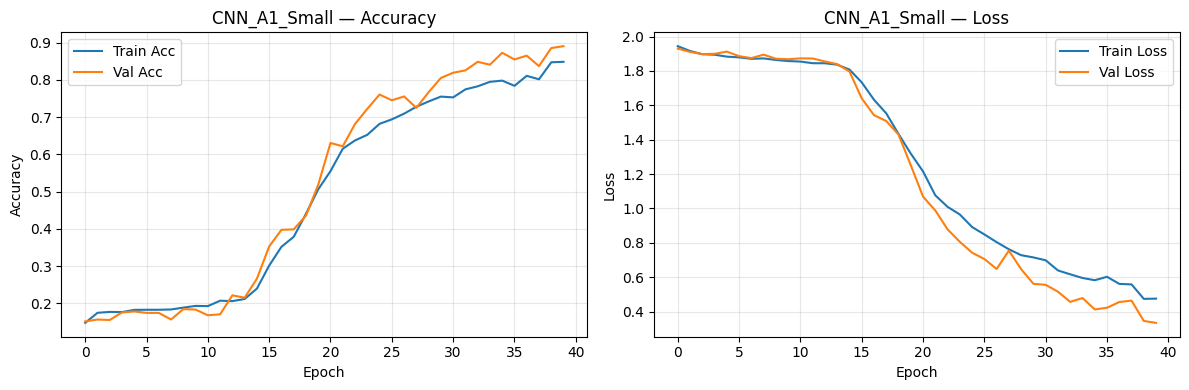


Model: CNN_A1_Small
  Test Accuracy : 0.9051
  Test Loss     : 0.3171
  Macro F1      : 0.9056
              precision    recall  f1-score   support

          10       0.88      0.92      0.90       121
         100       0.90      0.93      0.91       114
        1000       0.92      0.92      0.92       106
          20       0.88      0.84      0.86       116
          50       0.94      0.88      0.91       111
         500       0.94      0.93      0.94       109
        5000       0.87      0.91      0.89       113

    accuracy                           0.91       790
   macro avg       0.91      0.91      0.91       790
weighted avg       0.91      0.91      0.91       790



In [ ]:
CNN_CONFIGS = [
    # (label,         filters,            dropout, BatchNorm,  lr)
    ("CNN_A1_Small",  [32, 64],           0.3,     False,   0.001),
]

for name, filters, dropout, batchnorm, lr in CNN_CONFIGS:
    tf.keras.backend.clear_session()

    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    print(f"\n{'#'*60}")
    print(f"Training: {name}")
    print(f"  Filters={filters}  Dropout={dropout}  BatchNorm={batchnorm}, learning rate={lr}")
    print(f"{'#'*60}")

    model = build_custom_cnn(filters, len(filters), dropout, batchnorm, learning_rate=lr)
    model.summary()

    start = time.time()
    history = model.fit(
        train_gen_70,
        epochs=40,
        validation_data=val_gen_70,
        callbacks=get_callbacks(name),
        verbose=1
    )
    elapsed = time.time() - start
    print(f"Training time: {elapsed/60:.1f} min")

    plot_history(history, name)

    result = evaluate_model(model, test_gen_70, name)
    result["train_time_min"] = round(elapsed / 60, 1)
    all_results.append(result)

    del model   # free GPU memory


Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: CNN_A2_Medium
  Filters=[32, 64, 128]  Dropout=0.3  BatchNorm=True, learning rate=0.001
############################################################


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,215 (1.17 MB)

 Trainable params: 305,319 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 105s 723ms/step - accuracy: 0.2935 - loss: 1.7723 - val_accuracy: 0.1529 - val_loss: 2.3803 - learning_rate: 0.0010
Epoch 2/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 557ms/step - accuracy: 0.4477 - loss: 1.4584 - val_accuracy: 0.2166 - val_loss: 2.0807 - learning_rate: 0.0010
Epoch 3/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 551ms/step - accuracy: 0.5435 - loss: 1.2372 - val_accuracy: 0.2484 - val_loss: 1.9698 - learning_rate: 0.0010
Epoch 4/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 551ms/step - accuracy: 0.6235 - loss: 1.0595 - val_accuracy: 0.3987 - val_loss: 1.6809 - learning_rate: 0.0010
Epoch 5/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 545ms/step - accuracy: 0.6710 - loss: 0.9192 - val_accuracy: 0.5057 - val_loss: 1.2477 - learning_rate: 0.0010
Epoch 6/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 535ms/step - accuracy: 0.7327 - loss: 0.7708 - val_accuracy: 0.7541 - val_loss: 0.7434 - learning_rate: 0.0010
Epoch 7/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 551ms/step - accuracy: 0.

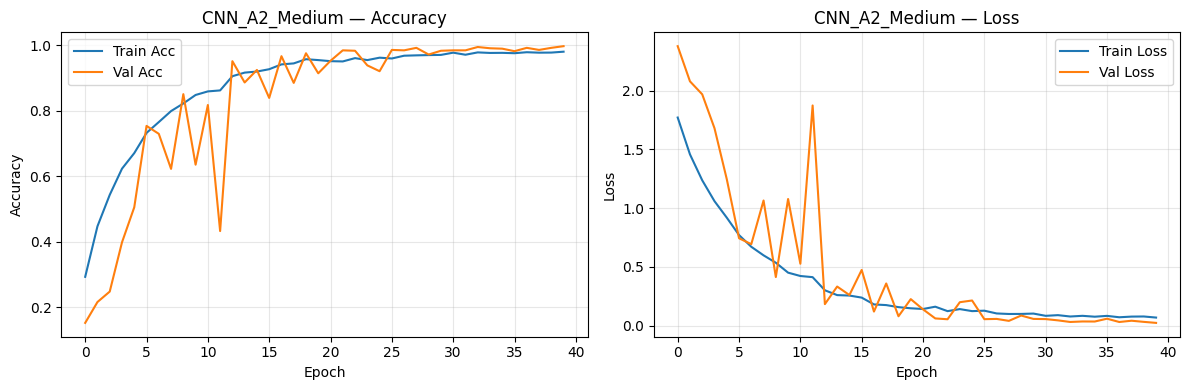


Model: CNN_A2_Medium
  Test Accuracy : 0.9848
  Test Loss     : 0.0415
  Macro F1      : 0.9848
              precision    recall  f1-score   support

          10       0.98      0.99      0.99       121
         100       0.97      1.00      0.99       114
        1000       0.98      0.98      0.98       106
          20       1.00      0.96      0.98       116
          50       0.99      0.98      0.99       111
         500       0.99      1.00      1.00       109
        5000       0.97      0.98      0.98       113

    accuracy                           0.98       790
   macro avg       0.98      0.98      0.98       790
weighted avg       0.98      0.98      0.98       790



In [ ]:
CNN_CONFIGS = [
    # (label,         filters,            dropout, BatchNorm,  lr)
    ("CNN_A2_Medium", [32, 64, 128],      0.3,     True,   0.001),
]

for name, filters, dropout, batchnorm, lr in CNN_CONFIGS:
    tf.keras.backend.clear_session()

    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    print(f"\n{'#'*60}")
    print(f"Training: {name}")
    print(f"  Filters={filters}  Dropout={dropout}  BatchNorm={batchnorm}, learning rate={lr}")
    print(f"{'#'*60}")

    model = build_custom_cnn(filters, len(filters), dropout, batchnorm, learning_rate=lr)
    model.summary()

    start = time.time()
    history = model.fit(
        train_gen_70,
        epochs=40,
        validation_data=val_gen_70,
        callbacks=get_callbacks(name),
        verbose=1
    )
    elapsed = time.time() - start
    print(f"Training time: {elapsed/60:.1f} min")

    plot_history(history, name)

    result = evaluate_model(model, test_gen_70, name)
    result["train_time_min"] = round(elapsed / 60, 1)
    all_results.append(result)

    del model   # free GPU memory


Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: CNN_A3_Deep
  Filters=[64, 128, 256]  Dropout=0.3  BatchNorm=True, learning rate=0.0005
############################################################


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,182,791 (4.51 MB)

 Trainable params: 1,180,999 (4.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 147s 944ms/step - accuracy: 0.3284 - loss: 1.7593 - val_accuracy: 0.1529 - val_loss: 2.5692 - learning_rate: 5.0000e-04
Epoch 2/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 129s 616ms/step - accuracy: 0.5154 - loss: 1.2892 - val_accuracy: 0.1414 - val_loss: 2.6227 - learning_rate: 5.0000e-04
Epoch 3/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 71s 614ms/step - accuracy: 0.5829 - loss: 1.1268 - val_accuracy: 0.1427 - val_loss: 3.3049 - learning_rate: 5.0000e-04
Epoch 4/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.6465 - loss: 0.9908
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 609ms/step - accuracy: 0.6465 - loss: 0.9966 - val_accuracy: 0.2000 - val_loss: 2.6538 - learning_rate: 5.0000e-04
Epoch 5/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 610ms/step - accuracy: 0.7207 - loss: 0.8102 - val_accuracy: 0.5057 - val_loss: 1.2948 - learning_rate: 2.5000e-04
Epoch 6/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 613ms/

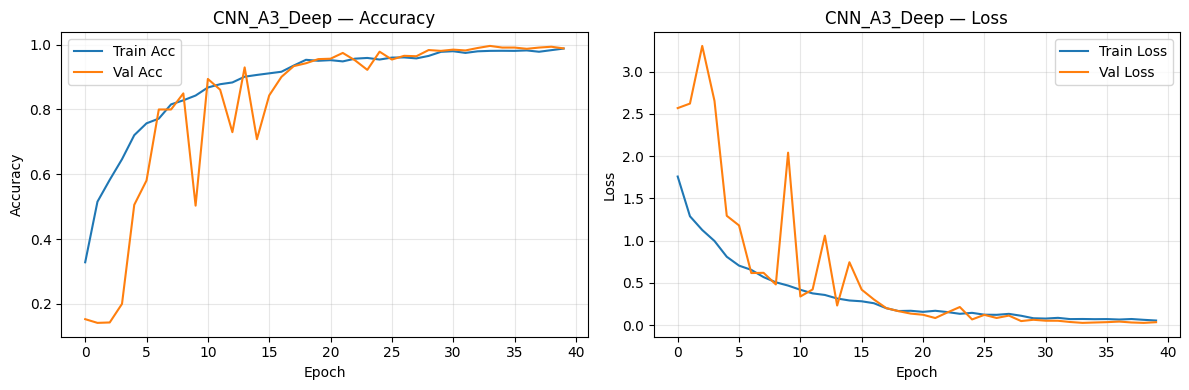


Model: CNN_A3_Deep
  Test Accuracy : 0.9886
  Test Loss     : 0.0312
  Macro F1      : 0.9885
              precision    recall  f1-score   support

          10       1.00      1.00      1.00       121
         100       0.97      1.00      0.99       114
        1000       0.99      0.98      0.99       106
          20       1.00      0.97      0.98       116
          50       0.98      0.98      0.98       111
         500       0.99      1.00      1.00       109
        5000       0.98      0.99      0.99       113

    accuracy                           0.99       790
   macro avg       0.99      0.99      0.99       790
weighted avg       0.99      0.99      0.99       790



In [ ]:
CNN_CONFIGS = [
    # (label,         filters,            dropout, BatchNorm,  lr)
    ("CNN_A3_Deep",   [64, 128, 256],     0.3,     True,   0.0005),
]

for name, filters, dropout, batchnorm, lr in CNN_CONFIGS:
    tf.keras.backend.clear_session()

    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    print(f"\n{'#'*60}")
    print(f"Training: {name}")
    print(f"  Filters={filters}  Dropout={dropout}  BatchNorm={batchnorm}, learning rate={lr}")
    print(f"{'#'*60}")

    model = build_custom_cnn(filters, len(filters), dropout, batchnorm, learning_rate=lr)
    model.summary()

    start = time.time()
    history = model.fit(
        train_gen_70,
        epochs=40,
        validation_data=val_gen_70,
        callbacks=get_callbacks(name),
        verbose=1
    )
    elapsed = time.time() - start
    print(f"Training time: {elapsed/60:.1f} min")

    plot_history(history, name)

    result = evaluate_model(model, test_gen_70, name)
    result["train_time_min"] = round(elapsed / 60, 1)
    all_results.append(result)

    del model   # free GPU memory


## SECTION 7 Model B — MobileNetV2 Transfer Learning
MobileNetV2 pretrained on ImageNet. Two-phase training:
1. **Feature extraction**: base frozen, only custom head trained (20 epochs)
2. **Fine-tuning**: top N layers of base unfrozen, trained at very low LR (15 epochs)

Three variants differ in how many base layers are unfrozen and the learning rate used in fine-tuning.

In [ ]:
def build_transfer_model(base_model_fn, model_name, preprocess_fn,
                         dense_units=128, base_trainable=False,
                         unfreeze_last_n=0, input_shape=(224, 224, 3)):
    """
    Generic transfer learning model builder.
    Phase 1: base_trainable=False (feature extraction)
    Phase 2: unfreeze_last_n layers for fine-tuning
    """
    base = base_model_fn(weights="imagenet", include_top=False,
                         input_shape=input_shape)
    base.trainable = base_trainable

    if base_trainable and unfreeze_last_n > 0:
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Lambda(preprocess_fn)(inputs)   # ← model-specific preprocessing baked in
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)
    return model, base

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: MNV2_B1 | Dense=128 | Unfreeze=20 | FT_LR=0.0001
############################################################
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

[Phase 1] Feature extraction...
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.4753 - loss: 1.4249 - val_accuracy: 0.6752 - val_loss: 0.9687 - learning_rate: 0.0010
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6814 - loss: 0.8791 - val_accuracy: 0.7350 - val_loss: 0.7710 - learning_rate: 0.0010
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7401 - loss: 0.7201 - val_accuracy: 0.7682 - val_loss: 0.6636 - learning_rate: 0.0010
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7578 - loss: 0.6443 - val_accuracy: 0.7694 - val_loss: 0.6420 - learning_rate: 0.0010


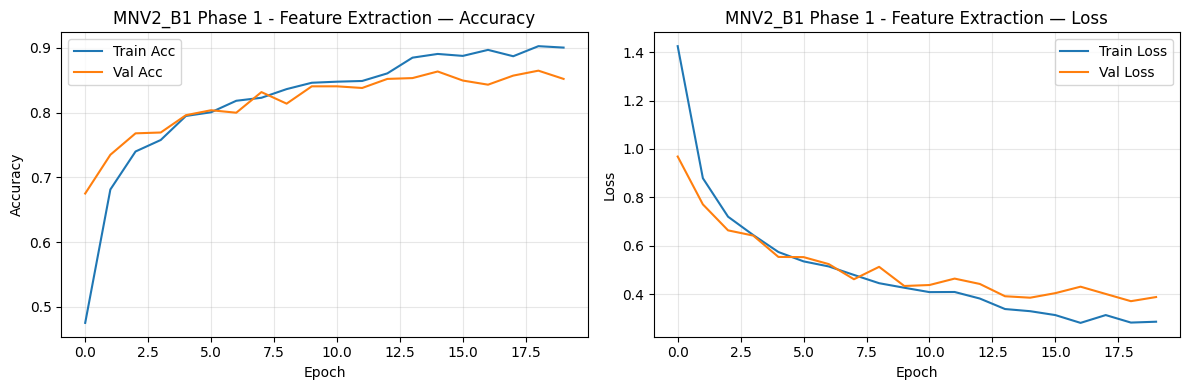


[Phase 2] Fine-tuning top 20 layers at LR=0.0001...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8417 - loss: 0.4302 - val_accuracy: 0.8535 - val_loss: 0.4043 - learning_rate: 1.0000e-04
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.8862 - loss: 0.3225 - val_accuracy: 0.9197 - val_loss: 0.2382 - learning_rate: 1.0000e-04
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9203 - loss: 0.2272 - val_accuracy: 0.9032 - val_loss: 0.2937 - learning_rate: 1.0000e-04
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9260 - loss: 0.2159 - val_accuracy: 0.9376 - val_loss: 0.2012 - learning_rate: 1.0000e-04
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9424 - loss: 0.1683 - val_accuracy: 0.9541 - val_loss: 0.1626 - learning_rate: 1.0000e-04
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9552 - loss: 0.1299 - val_accuracy: 0.9376 - val_loss: 0.1928 - learning_rate: 1.0000e-04
Epoch

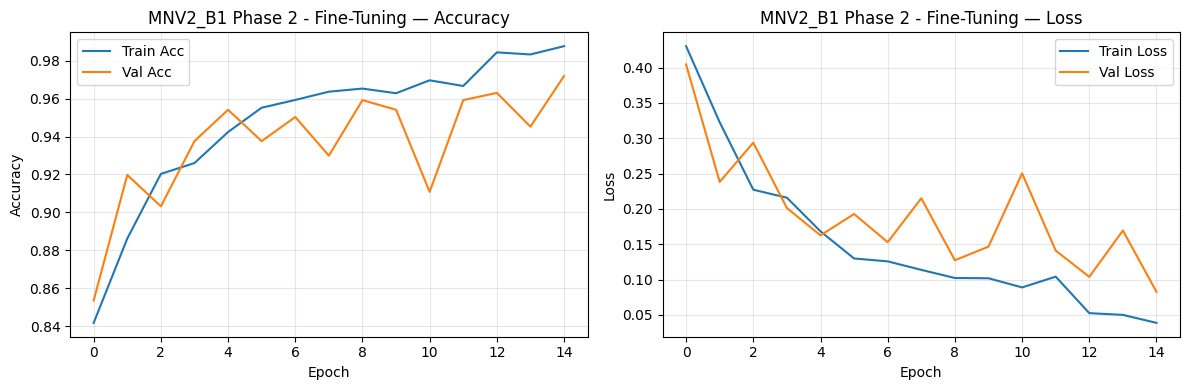


Model: MNV2_B1
  Test Accuracy : 0.9646
  Test Loss     : 0.1162
  Macro F1      : 0.9645
              precision    recall  f1-score   support

          10       0.95      0.98      0.97       121
         100       0.97      0.98      0.98       114
        1000       0.97      0.96      0.97       106
          20       0.96      0.94      0.95       116
          50       0.94      0.97      0.96       111
         500       0.96      0.94      0.95       109
        5000       0.99      0.97      0.98       113

    accuracy                           0.96       790
   macro avg       0.96      0.96      0.96       790
weighted avg       0.96      0.96      0.96       790

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: MNV2_B2 | Dense=256 | Unfreeze=30 | FT_LR=5e-05
############################################################

[Phase

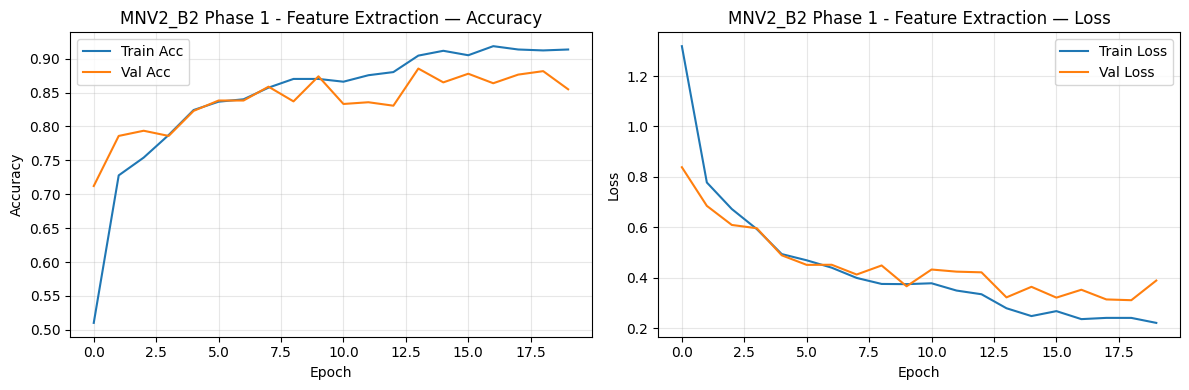


[Phase 2] Fine-tuning top 30 layers at LR=5e-05...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9050 - loss: 0.2724 - val_accuracy: 0.9070 - val_loss: 0.2511 - learning_rate: 5.0000e-05
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9287 - loss: 0.1938 - val_accuracy: 0.9223 - val_loss: 0.2329 - learning_rate: 5.0000e-05
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9465 - loss: 0.1494 - val_accuracy: 0.9006 - val_loss: 0.2629 - learning_rate: 5.0000e-05
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9530 - loss: 0.1346 - val_accuracy: 0.9083 - val_loss: 0.2701 - learning_rate: 5.0000e-05
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9528 - loss: 0.1263 - val_accuracy: 0.9389 - val_loss: 0.1610 - learning_rate: 5.0000e-05
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9683 - loss: 0.0976 - val_accuracy: 0.9465 - val_loss: 0.1571 - learning_rate: 5.0000e-05
Epoch 

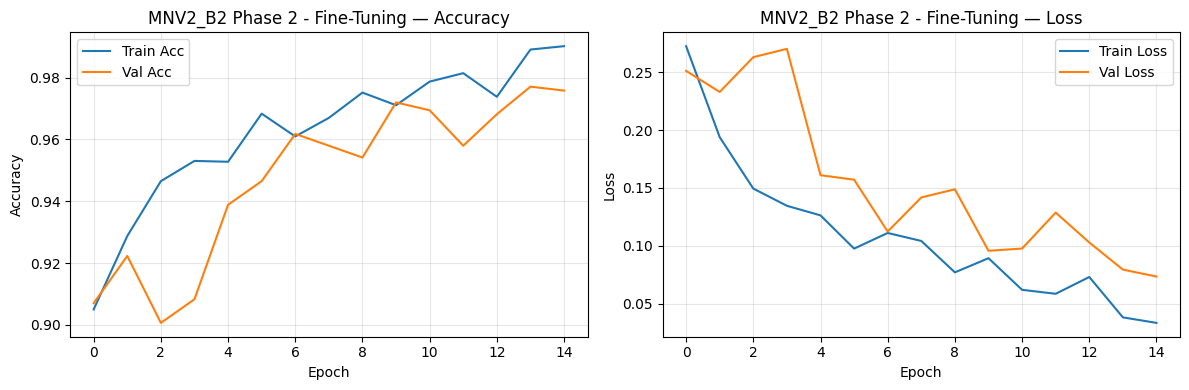


Model: MNV2_B2
  Test Accuracy : 0.9759
  Test Loss     : 0.0882
  Macro F1      : 0.9759
              precision    recall  f1-score   support

          10       0.99      0.98      0.99       121
         100       1.00      0.98      0.99       114
        1000       0.97      0.98      0.98       106
          20       0.99      0.94      0.96       116
          50       0.92      0.96      0.94       111
         500       0.97      0.99      0.98       109
        5000       0.98      0.99      0.99       113

    accuracy                           0.98       790
   macro avg       0.98      0.98      0.98       790
weighted avg       0.98      0.98      0.98       790

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: MNV2_B3 | Dense=128 | Unfreeze=50 | FT_LR=1e-05
############################################################

[Phase

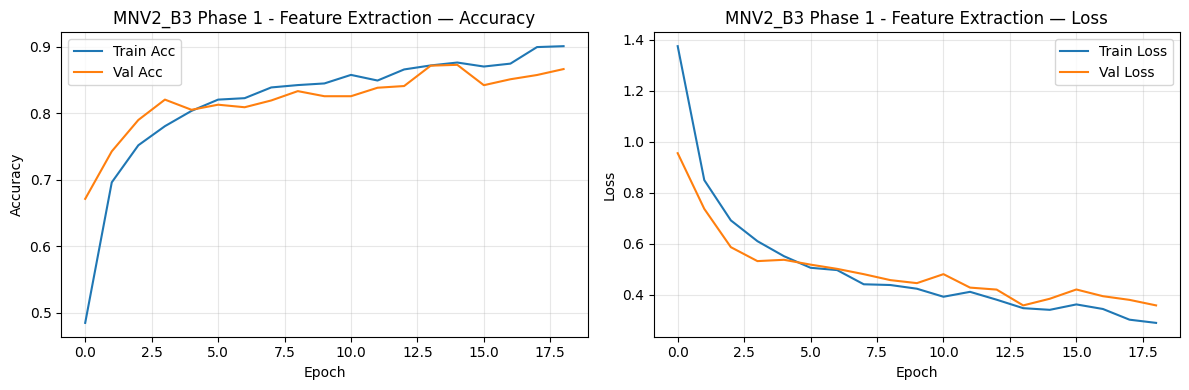


[Phase 2] Fine-tuning top 50 layers at LR=1e-05...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.8960 - loss: 0.3082 - val_accuracy: 0.8892 - val_loss: 0.2921 - learning_rate: 1.0000e-05
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9148 - loss: 0.2348 - val_accuracy: 0.9248 - val_loss: 0.2439 - learning_rate: 1.0000e-05
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9266 - loss: 0.2185 - val_accuracy: 0.9274 - val_loss: 0.2086 - learning_rate: 1.0000e-05
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9372 - loss: 0.1759 - val_accuracy: 0.9427 - val_loss: 0.1749 - learning_rate: 1.0000e-05
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9405 - loss: 0.1779 - val_accuracy: 0.9376 - val_loss: 0.1930 - learning_rate: 1.0000e-05
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9413 - loss: 0.1651 - val_accuracy: 0.9414 - val_loss: 0.1663 - learning_rate: 1.0000e-05
Epoch 

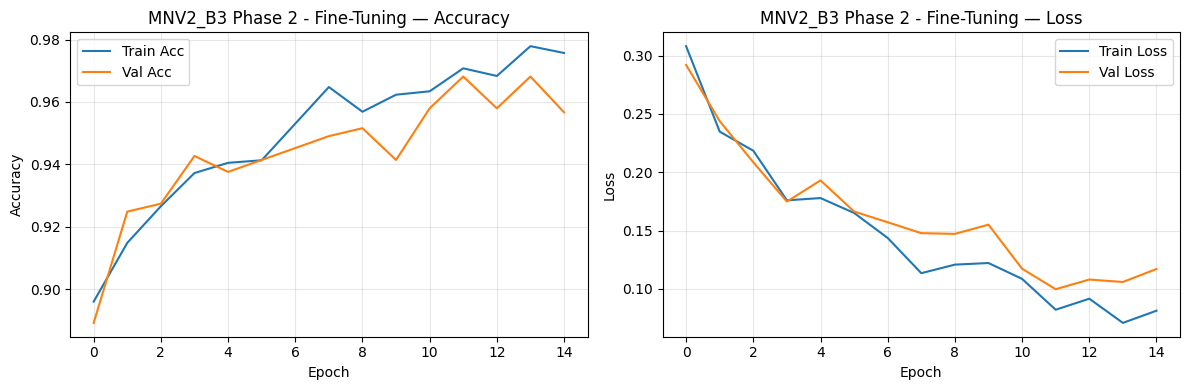


Model: MNV2_B3
  Test Accuracy : 0.9557
  Test Loss     : 0.1128
  Macro F1      : 0.9553
              precision    recall  f1-score   support

          10       0.96      0.98      0.97       121
         100       0.95      0.98      0.97       114
        1000       0.95      0.92      0.94       106
          20       0.99      0.91      0.95       116
          50       0.95      0.94      0.95       111
         500       0.90      0.98      0.94       109
        5000       0.99      0.97      0.98       113

    accuracy                           0.96       790
   macro avg       0.96      0.96      0.96       790
weighted avg       0.96      0.96      0.96       790



In [ ]:
MOBILE_CONFIGS = [
    # (label,         dense, unfreeze_n, finetune_lr)
    ("MNV2_B1",       128,   20,         1e-4),
    ("MNV2_B2",       256,   30,         5e-5),
    ("MNV2_B3",       128,   50,         1e-5),
]

for name, dense, unfreeze_n, ft_lr in MOBILE_CONFIGS:
    tf.keras.backend.clear_session()

    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    print(f"\n{'#'*60}")
    print(f"Training: {name} | Dense={dense} | Unfreeze={unfreeze_n} | FT_LR={ft_lr}")
    print(f"{'#'*60}")

    # ── Phase 1: Feature Extraction ──────────────────────────────────────────
    model, base = build_transfer_model(MobileNetV2, name,
                                       preprocess_fn=mnv2_preprocess,
                                       dense_units=dense, base_trainable=False)
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])

    print("\n[Phase 1] Feature extraction...")
    start = time.time()
    h1 = model.fit(train_gen_70, epochs=20, validation_data=val_gen_70,
                   callbacks=get_callbacks(name + "_phase1"), verbose=1)
    plot_history(h1, name, phase="Phase 1 - Feature Extraction")

    # ── Phase 2: Fine-tuning ─────────────────────────────────────────────────
    base.trainable = True
    for layer in base.layers[:-unfreeze_n]:
        layer.trainable = False

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(optimizer=optimizers.Adam(ft_lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])

    print(f"\n[Phase 2] Fine-tuning top {unfreeze_n} layers at LR={ft_lr}...")
    h2 = model.fit(train_gen_70, epochs=15, validation_data=val_gen_70,
                   callbacks=get_callbacks(name), verbose=1)
    elapsed = time.time() - start
    plot_history(h2, name, phase="Phase 2 - Fine-Tuning")

    result = evaluate_model(model, test_gen_70, name)
    result["train_time_min"] = round(elapsed / 60, 1)
    all_results.append(result)

    del model

## SECTION 8 Model C — EfficientNetB0 Transfer Learning
EfficientNetB0 uses compound scaling — balancing width, depth, and resolution.
Same two-phase training strategy as MobileNetV2, with different fine-tuning configurations.

Note: EfficientNet includes its own normalization internally,
so input preprocessing uses rescale=1./255 as before.

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: EffB0_C1 | Dense=128 | Unfreeze=20 | FT_LR=0.0001
############################################################
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 833ms/step - accuracy: 0.5334 - loss: 1.2949 - val_accuracy: 0.7682 - val_loss: 0.7253 - learning_rate: 0.0010
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 521ms/step - accuracy: 0.7535 - loss: 0.7331 - val_accuracy: 0.8433 - val_loss: 0.5193 - learning_rate: 0.0010
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 514ms/step - accuracy: 0.8135 - loss: 0.5610 - val_accuracy: 0.8841 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 509ms/step - accuracy: 0.8406 - loss: 0.4664 - val_accuracy: 0.8790 - val_loss: 0.3672 - learning_rate: 0.0010
Epoch 5/20
115/115 ━━

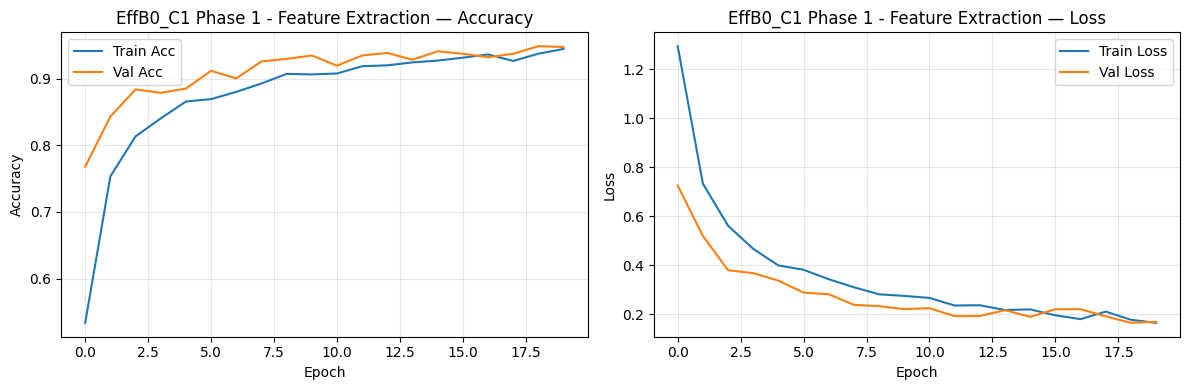

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 106s 716ms/step - accuracy: 0.9454 - loss: 0.1583 - val_accuracy: 0.9376 - val_loss: 0.1966 - learning_rate: 1.0000e-04
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 515ms/step - accuracy: 0.9552 - loss: 0.1267 - val_accuracy: 0.9452 - val_loss: 0.1658 - learning_rate: 1.0000e-04
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 517ms/step - accuracy: 0.9656 - loss: 0.0988 - val_accuracy: 0.9656 - val_loss: 0.1170 - learning_rate: 1.0000e-04
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 514ms/step - accuracy: 0.9722 - loss: 0.0764 - val_accuracy: 0.9618 - val_loss: 0.1345 - learning_rate: 1.0000e-04
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 517ms/step - accuracy: 0.9743 - loss: 0.0705 - val_accuracy: 0.9643 - val_loss: 0.1079 - learning_rate: 1.0000e-04
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 514ms/step - accuracy: 0.9782 - loss: 0.0702 - val_accuracy: 0.9682 - val_loss: 0.1010 - learning_rate: 1.0000e-04
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 5

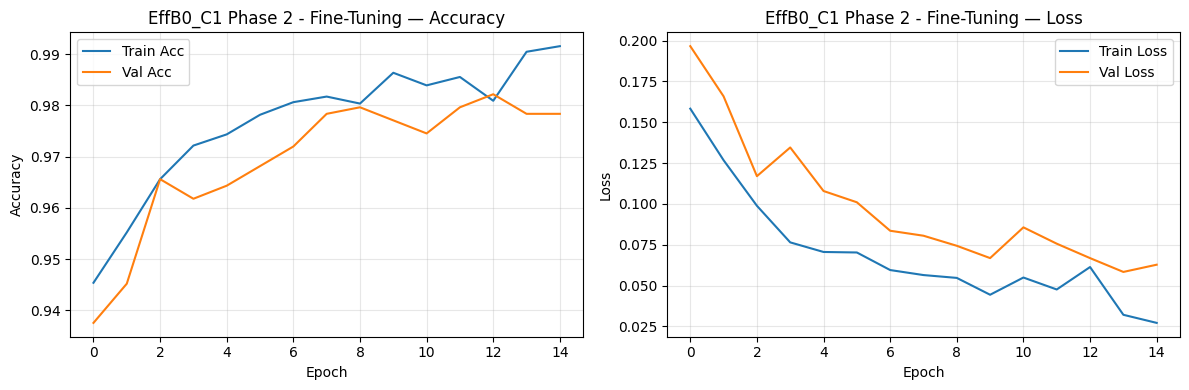


Model: EffB0_C1
  Test Accuracy : 0.9911
  Test Loss     : 0.0298
  Macro F1      : 0.9913
              precision    recall  f1-score   support

          10       0.99      0.98      0.99       121
         100       0.99      0.99      0.99       114
        1000       1.00      1.00      1.00       106
          20       0.97      1.00      0.99       116
          50       1.00      0.98      0.99       111
         500       1.00      0.99      1.00       109
        5000       0.98      0.99      0.99       113

    accuracy                           0.99       790
   macro avg       0.99      0.99      0.99       790
weighted avg       0.99      0.99      0.99       790

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: EffB0_C2 | Dense=256 | Unfreeze=30 | FT_LR=5e-05
############################################################
Epoch

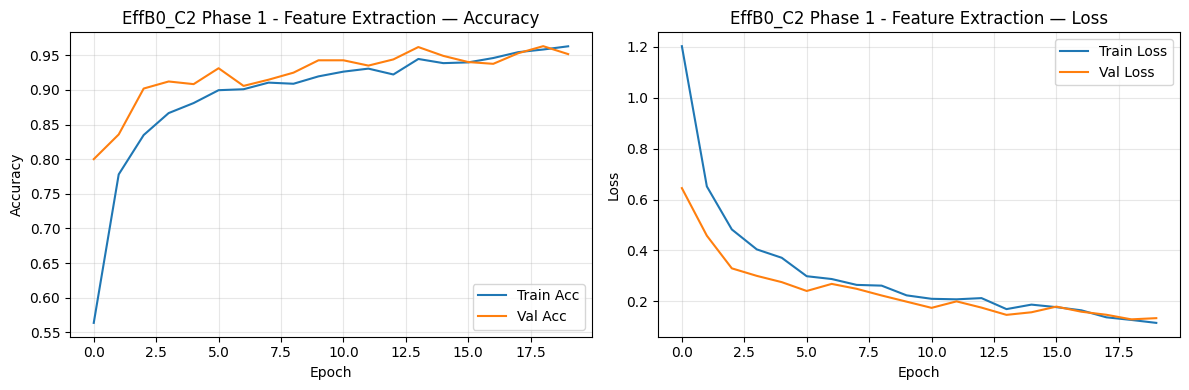

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 111s 746ms/step - accuracy: 0.9675 - loss: 0.1035 - val_accuracy: 0.9592 - val_loss: 0.1272 - learning_rate: 5.0000e-05
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 61s 532ms/step - accuracy: 0.9716 - loss: 0.0922 - val_accuracy: 0.9669 - val_loss: 0.0891 - learning_rate: 5.0000e-05
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 538ms/step - accuracy: 0.9760 - loss: 0.0813 - val_accuracy: 0.9720 - val_loss: 0.0777 - learning_rate: 5.0000e-05
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 540ms/step - accuracy: 0.9793 - loss: 0.0661 - val_accuracy: 0.9771 - val_loss: 0.0697 - learning_rate: 5.0000e-05
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 537ms/step - accuracy: 0.9809 - loss: 0.0629 - val_accuracy: 0.9758 - val_loss: 0.0896 - learning_rate: 5.0000e-05
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 534ms/step - accuracy: 0.9803 - loss: 0.0608 - val_accuracy: 0.9707 - val_loss: 0.0907 - learning_rate: 5.0000e-05
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 50

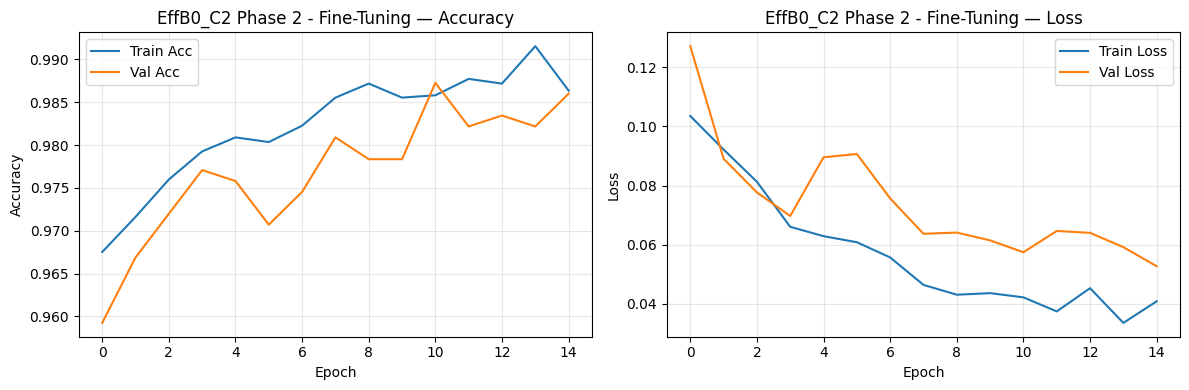


Model: EffB0_C2
  Test Accuracy : 0.9899
  Test Loss     : 0.0373
  Macro F1      : 0.9898
              precision    recall  f1-score   support

          10       1.00      0.98      0.99       121
         100       0.99      1.00      1.00       114
        1000       0.98      0.99      0.99       106
          20       0.99      1.00      1.00       116
          50       0.98      0.96      0.97       111
         500       1.00      1.00      1.00       109
        5000       0.98      0.99      0.99       113

    accuracy                           0.99       790
   macro avg       0.99      0.99      0.99       790
weighted avg       0.99      0.99      0.99       790

Found 3663 images belonging to 7 classes.
Found 785 images belonging to 7 classes.
Found 790 images belonging to 7 classes.

############################################################
Training: EffB0_C3 | Dense=128 | Unfreeze=50 | FT_LR=1e-05
############################################################
Epoch

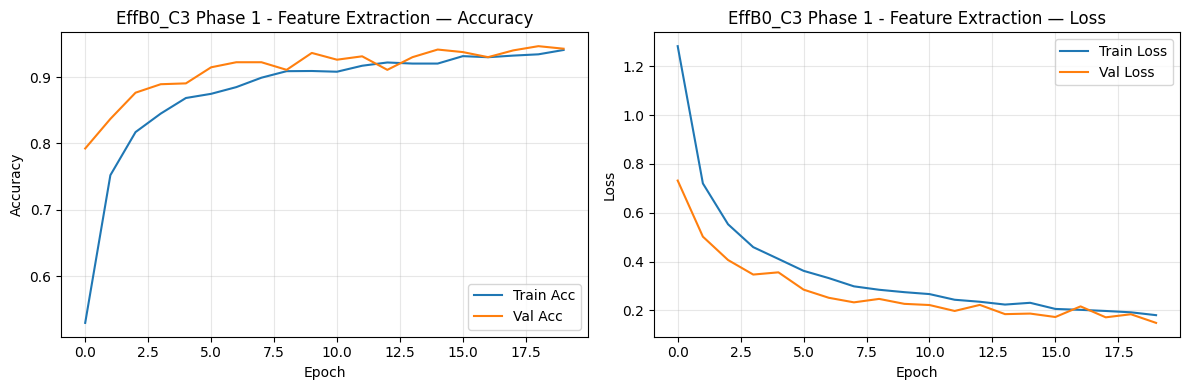

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 118s 773ms/step - accuracy: 0.9517 - loss: 0.1512 - val_accuracy: 0.9592 - val_loss: 0.1306 - learning_rate: 1.0000e-05
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 541ms/step - accuracy: 0.9582 - loss: 0.1296 - val_accuracy: 0.9580 - val_loss: 0.1185 - learning_rate: 1.0000e-05
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 66s 570ms/step - accuracy: 0.9599 - loss: 0.1186 - val_accuracy: 0.9631 - val_loss: 0.1081 - learning_rate: 1.0000e-05
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 542ms/step - accuracy: 0.9651 - loss: 0.1057 - val_accuracy: 0.9669 - val_loss: 0.1039 - learning_rate: 1.0000e-05
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 61s 533ms/step - accuracy: 0.9659 - loss: 0.0990 - val_accuracy: 0.9682 - val_loss: 0.1045 - learning_rate: 1.0000e-05
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 540ms/step - accuracy: 0.9702 - loss: 0.0917 - val_accuracy: 0.9720 - val_loss: 0.0982 - learning_rate: 1.0000e-05
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 5

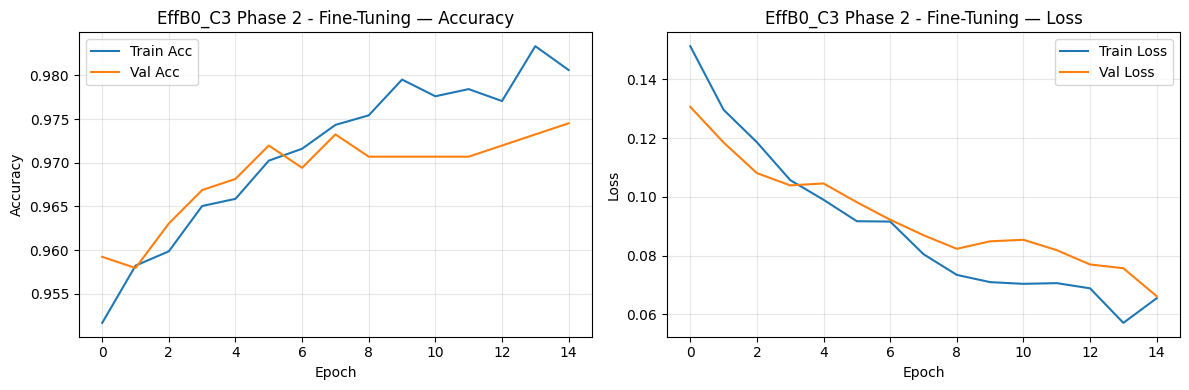


Model: EffB0_C3
  Test Accuracy : 0.9823
  Test Loss     : 0.0494
  Macro F1      : 0.9820
              precision    recall  f1-score   support

          10       0.99      0.99      0.99       121
         100       0.98      1.00      0.99       114
        1000       0.99      0.97      0.98       106
          20       0.98      0.99      0.99       116
          50       0.98      0.95      0.97       111
         500       0.99      0.96      0.98       109
        5000       0.96      1.00      0.98       113

    accuracy                           0.98       790
   macro avg       0.98      0.98      0.98       790
weighted avg       0.98      0.98      0.98       790



In [ ]:
EFFNET_CONFIGS = [
    # (label,        dense, unfreeze_n, finetune_lr)
    ("EffB0_C1",     128,   20,         1e-4),
    ("EffB0_C2",     256,   30,         5e-5),
    ("EffB0_C3",     128,   50,         1e-5)
]

for name, dense, unfreeze_n, ft_lr in EFFNET_CONFIGS:

    tf.keras.backend.clear_session()

    train_gen_70, val_gen_70, test_gen_70 = make_generators(SPLIT_70_PATH)

    print(f"\n{'#'*60}")
    print(f"Training: {name} | Dense={dense} | Unfreeze={unfreeze_n} | FT_LR={ft_lr}")
    print(f"{'#'*60}")

    # Phase 1
    model, base = build_transfer_model(EfficientNetB0, name,
                                       preprocess_fn=eff_preprocess,
                                       dense_units=dense, base_trainable=False)
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])

    start = time.time()
    h1 = model.fit(train_gen_70, epochs=20, validation_data=val_gen_70,
                   callbacks=get_callbacks(name + "_phase1"), verbose=1)
    plot_history(h1, name, phase="Phase 1 - Feature Extraction")

    # Phase 2
    base.trainable = True
    for layer in base.layers[:-unfreeze_n]:
        layer.trainable = False

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False  # BN always uses stored moving averages

    model.compile(optimizer=optimizers.Adam(ft_lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_gen_70, epochs=15, validation_data=val_gen_70,
                   callbacks=get_callbacks(name), verbose=1)
    elapsed = time.time() - start
    plot_history(h2, name, phase="Phase 2 - Fine-Tuning")

    result = evaluate_model(model, test_gen_70, name)
    result["train_time_min"] = round(elapsed / 60, 1)
    all_results.append(result)

    del model

## SECTION 9 — Comparative Analysis


In [ ]:
# ─── Build summary table ─────────────────────────────────────────────────────
summary_df = pd.DataFrame([{
    "Model":         r["model"],
    "Test Accuracy": f"{r['test_acc']*100:.2f}%",
    "Test Loss":     f"{r['test_loss']:.4f}",
    "Macro F1":      f"{r['macro_f1']:.4f}",
    "Train Time (min)": r["train_time_min"]
} for r in all_results])

print("\n" + "="*70)
print("COMPARATIVE RESULTS — ALL 9 MODELS")
print("="*70)
print(summary_df.to_string(index=False))


COMPARATIVE RESULTS — ALL 9 MODELS
        Model Test Accuracy Test Loss Macro F1  Train Time (min)
 CNN_A1_Small        90.51%    0.3171   0.9056                 0
CNN_A2_Medium        98.48%    0.0415   0.9848                 0
  CNN_A3_Deep        98.86%    0.0312   0.9885                 0
      MNV2_B1        96.46%    0.1162   0.9645                 0
      MNV2_B2        97.59%    0.0882   0.9759                 0
      MNV2_B3        95.57%    0.1128   0.9553                 0
     EffB0_C1        99.11%    0.0298   0.9913                 0
     EffB0_C2        98.99%    0.0373   0.9898                 0
     EffB0_C3        98.23%    0.0494   0.9820                 0


In [37]:
# ─── Bar chart comparison (With Visible Axes) ────────────────────────────────

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Extract data
model_names  = [r["model"]    for r in all_results]
test_accs    = [r["test_acc"] for r in all_results]
macro_f1s    = [r["macro_f1"] for r in all_results]

# Helper to automatically assign your colors and legend labels
def get_style(model_name):
    if model_name.startswith("CNN"):
        return "#7F77DD", "Custom CNN"
    elif model_name.startswith("MNV2"):
        return "#1D9E75", "MobileNetV2"
    else:
        return "#D85A30", "EfficientNetB0"

# 2. Set up the side-by-side layout
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Test Accuracy — All Models", "Macro F1 Score — All Models")
)

# 3. Add the bars
families_added = set()

for i, model in enumerate(model_names):
    color, family = get_style(model)
    show_legend = family not in families_added
    families_added.add(family)

    # Left Chart: Test Accuracy
    fig.add_trace(
        go.Bar(
            x=[model], y=[test_accs[i]],
            marker_color=color,
            marker_line=dict(color="white", width=0.5),
            name=family,
            legendgroup=family,
            showlegend=show_legend,
            hovertemplate=f"<b>{model}</b><br>Accuracy: %{{y:.2%}}<extra></extra>"
        ),
        row=1, col=1
    )

    # Right Chart: Macro F1
    fig.add_trace(
        go.Bar(
            x=[model], y=[macro_f1s[i]],
            marker_color=color,
            marker_line=dict(color="white", width=0.5),
            name=family,
            legendgroup=family,
            showlegend=False,
            hovertemplate=f"<b>{model}</b><br>F1 Score: %{{y:.4f}}<extra></extra>"
        ),
        row=1, col=2
    )

# 4. Style the overall layout
fig.update_layout(
    template="plotly_white",
    height=450,
    width=1000,
    legend=dict(
        orientation="h", yanchor="bottom", y=1.15,
        xanchor="center", x=0.5
    ),
    margin=dict(t=120)
)

# 5. Format the axes (Adding the solid visible lines here)
# Left Chart Axes
fig.update_yaxes(
    title_text="Accuracy", range=[0, 1], tickformat=".0%",
    showline=True, linewidth=2, linecolor='black', # Draws the Y-axis line
    row=1, col=1
)
fig.update_xaxes(
    tickangle=45,
    showline=True, linewidth=2, linecolor='black', # Draws the X-axis line
    row=1, col=1
)

# Right Chart Axes
fig.update_yaxes(
    title_text="F1 Score", range=[0, 1],
    showline=True, linewidth=2, linecolor='black', # Draws the Y-axis line
    row=1, col=2
)
fig.update_xaxes(
    tickangle=45,
    showline=True, linewidth=2, linecolor='black', # Draws the X-axis line
    row=1, col=2
)

fig.show()

Best model: EffB0_C1 (99.11%)


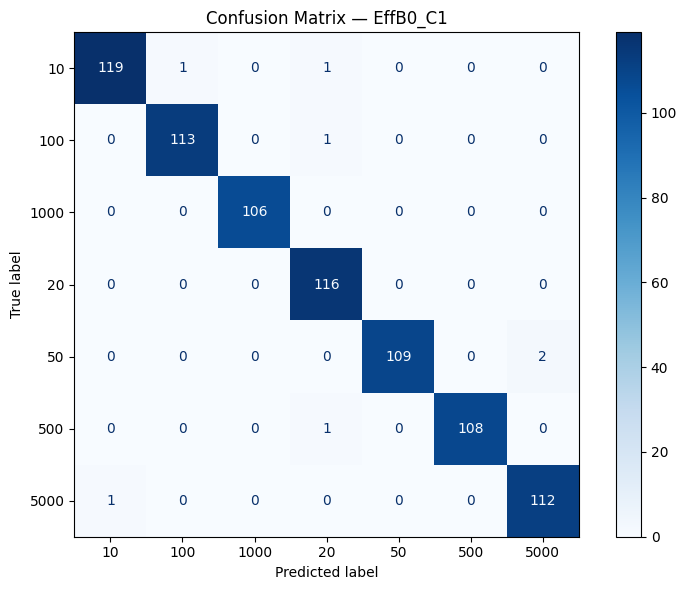

In [ ]:
# ─── Confusion matrix for the best model ────────────────────────────────────
best_result = max(all_results, key=lambda x: x["test_acc"])
print(f"Best model: {best_result['model']} ({best_result['test_acc']*100:.2f}%)")

cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_result['model']}")
plt.tight_layout()
plt.show()

In [35]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix as sk_cm

# 1. Set global clean light theme
pio.templates.default = "plotly_white"

# 2. Configuration to hide zoom/pan/lasso tools but KEEP hover info
CLEAN_CONFIG = {'displayModeBar': False}

# ── Constants & Data Setup ───────────────────────────────────────────────────
CURRENCY_CLASSES = ["Rs.10", "Rs.20", "Rs.50", "Rs.100", "Rs.500", "Rs.1000", "Rs.5000"]

FAMILY_COLORS = {"CNN": "#9B59B6", "MNV2": "#1ABC9C", "EffB0": "#E74C3C"}

def get_family(model_name: str) -> str:
    for fam in FAMILY_COLORS.keys():
        if model_name.startswith(fam): return fam
    return "Unknown"

df_results = pd.DataFrame([{
    "Model": r["model"],
    "Family": get_family(r["model"]),
    "Test Accuracy": round(r["test_acc"] * 100, 4),
    "Test Loss": round(r["test_loss"], 4),
    "Macro F1": round(r["macro_f1"] * 100, 4),
    "Train Time (min)": r.get("train_time_min", 0),
    "y_true": r["y_true"],
    "y_pred": r["y_pred"],
} for r in all_results])

print(f"✅ Loaded {len(df_results)} models into visualisation DataFrame.")


# ════════════════════════════════════════════════════════════════════════════
# VIZ 1 — Training Time vs. Accuracy: Scatter Plot
# ════════════════════════════════════════════════════════════════════════════
def build_beautiful_scatter(df):
    df_plot = df.copy()
    if df_plot["Train Time (min)"].max() == 0:
        df_plot["Train Time (min)"] = np.random.default_rng(42).uniform(5, 60, size=len(df_plot))

    fig = px.scatter(
        df_plot, x="Train Time (min)", y="Test Accuracy",
        color="Family", color_discrete_map=FAMILY_COLORS,
        hover_name="Model",
        hover_data={"Family": False, "Test Accuracy": ":.2f", "Train Time (min)": ":.1f"},
        title="⏱️ Training Time vs. Test Accuracy"
    )

    fig.update_traces(
        marker=dict(size=16, line=dict(width=1.5, color="white"), opacity=0.9)
    )
    fig.update_layout(
        width=750, height=500, title_x=0.5,
        xaxis=dict(showgrid=True, gridcolor="#E5E5E5", zeroline=False),
        yaxis=dict(showgrid=True, gridcolor="#E5E5E5", zeroline=False),
        plot_bgcolor="white", paper_bgcolor="white"
    )
    return fig

build_beautiful_scatter(df_results).show(config=CLEAN_CONFIG)


# ════════════════════════════════════════════════════════════════════════════
# VIZ 2 — Interactive Confusion Matrix
# ════════════════════════════════════════════════════════════════════════════
def build_confusion_heatmap(entry):
    cm = sk_cm(entry["y_true"], entry["y_pred"], labels=list(range(len(CURRENCY_CLASSES))))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    fig = go.Figure(go.Heatmap(
        z=cm_norm, x=CURRENCY_CLASSES, y=CURRENCY_CLASSES,
        text=cm, texttemplate="%{text}", colorscale="Blues", showscale=True,
        hovertemplate="Predicted: %{x}<br>Actual: %{y}<br>Count: %{text}<br>Rate: %{z:.1%}<extra></extra>"
    ))

    fig.update_layout(
        title={"text": f"🔢 Confusion Matrix — {entry['model']} | Acc: {entry['test_acc']*100:.1f}%", "x": 0.5},
        xaxis_title="Predicted Label", yaxis_title="True Label", yaxis_autorange="reversed",
        width=650, height=600, paper_bgcolor="white"
    )
    return fig

dropdown = widgets.Dropdown(options=df_results["Model"].tolist(), description="Select Model:")
cm_output = widgets.Output()

def on_model_change(change):
    entry = next((r for r in all_results if r["model"] == change["new"]), None)
    if entry:
        with cm_output:
            clear_output(wait=True)
            build_confusion_heatmap(entry).show(config=CLEAN_CONFIG)

dropdown.observe(on_model_change, names="value")
display(dropdown, cm_output)
on_model_change({"new": dropdown.value})


✅ Loaded 9 models into visualisation DataFrame.


Dropdown(description='Select Model:', options=('CNN_A1_Small', 'CNN_A2_Medium', 'CNN_A3_Deep', 'MNV2_B1', 'MNV…

Output()

In [34]:
# ════════════════════════════════════════════════════════════════════════════
# VIZ 3 — Radar Chart: Best Model vs Baseline (Vibrant Colors)
# ════════════════════════════════════════════════════════════════════════════
def build_beautiful_radar(df):
    best = df.loc[df["Test Accuracy"].idxmax()]
    baseline = df[df["Model"] == "CNN_A1_Small"]
    baseline = baseline.iloc[0] if not baseline.empty else df.loc[df["Test Accuracy"].idxmin()]

    def extract_metrics(row):
        eff = 100.0 / row["Train Time (min)"] if row["Train Time (min)"] > 0 else 50.0
        return [row["Test Accuracy"], row["Macro F1"], max(0, 100 - row["Test Loss"] * 100), eff]

    axes = ["Test Accuracy", "Macro F1", "Inverted Loss", "Efficiency", "Test Accuracy"]
    bvals = extract_metrics(best)
    blvals = extract_metrics(baseline)

    max_eff = max(bvals[3], blvals[3], 1e-9)
    bvals[3], blvals[3] = (bvals[3] / max_eff) * 100, (blvals[3] / max_eff) * 100
    bvals.append(bvals[0])
    blvals.append(blvals[0])

    fig = go.Figure()

    # BEST MODEL: Vibrant Electric Blue, thicker line, stronger opacity
    fig.add_trace(go.Scatterpolar(
        r=bvals, theta=axes, fill="toself", mode="lines+markers",
        line=dict(color="#0066FF", width=3),
        fillcolor="rgba(0, 102, 255, 0.45)",
        marker=dict(size=9, symbol="circle", color="#0066FF", line=dict(width=1.5, color="white")),
        name=f"⭐ Best: {best['Model']}", hovertemplate="%{theta}: %{r:.1f}<extra></extra>"
    ))

    # BASELINE MODEL: Vibrant Crimson Red, dashed line, stronger opacity
    fig.add_trace(go.Scatterpolar(
        r=blvals, theta=axes, fill="toself", mode="lines+markers",
        line=dict(color="#FF0044", width=2.5, dash="dash"),
        fillcolor="rgba(255, 0, 68, 0.35)",
        marker=dict(size=8, symbol="circle-open", color="#FF0044", line=dict(width=2.5)),
        name=f"Baseline: {baseline['Model']}", hovertemplate="%{theta}: %{r:.1f}<extra></extra>"
    ))

    fig.update_layout(
        polar=dict(
            gridshape='linear',
            bgcolor="#f8f9fa",
            radialaxis=dict(visible=True, range=[0, 100], gridcolor="white", linecolor="white", ticksuffix="%"),
            angularaxis=dict(gridcolor="white", linecolor="white", tickfont=dict(size=12))
        ),
        title={"text": "🕸️ Radar Chart — Best vs Baseline", "x": 0.5},
        width=700, height=550,
        paper_bgcolor="white"
    )
    return fig

build_beautiful_radar(df_results).show(config=CLEAN_CONFIG)


## SECTION 10 Split Ratio Investigation
We take the best performing model architecture and retrain it using a different
train/val/test split (80/10/10 vs the original 70/15/15) to study how the ratio
affects final test accuracy.

In [ ]:
# ─── Build generators for the 80/10/10 split ────────────────────────────────
train_gen_80, val_gen_80, test_gen_80 = make_generators(SPLIT_80_PATH)

# ─── Identify the best model's config and retrain it ────────────────────────
# (Edit the name/config below to match whichever won in Section 9)
# For example, if EffB0_C2 won, rebuild EfficientNetB0 with dense=256, unfreeze=30

BEST_NAME = best_result["model"]
print(f"Retraining {BEST_NAME} architecture on 80/10/10 split...")

# Rebuild the best model (adjust these params to match the winner's config)
# Phase 1
model_80, base_80 = build_transfer_model(EfficientNetB0,   # swap to MobileNetV2 if needed
                                          "Best_80split_phase1",
                                         preprocess_fn=eff_preprocess, #correct preprocess
                                          dense_units=128,   # match winner's dense
                                          base_trainable=False)
model_80.compile(optimizer=optimizers.Adam(1e-3),
                 loss="categorical_crossentropy", metrics=["accuracy"])

h1_80 = model_80.fit(train_gen_80, epochs=20, validation_data=val_gen_80,
                     callbacks=get_callbacks("Best_80split_phase1"), verbose=1)
# Phase 2
base_80.trainable = True
for layer in base_80.layers[:-20]:    # match winner's unfreeze_n
    layer.trainable = False

for layer in base_80.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

model_80.compile(optimizer=optimizers.Adam(1e-4),   # match winner's ft_lr
                 loss="categorical_crossentropy", metrics=["accuracy"])

h2_80 = model_80.fit(train_gen_80, epochs=15, validation_data=val_gen_80,
                     callbacks=get_callbacks("Best_80split"), verbose=1)

result_80 = evaluate_model(model_80, test_gen_80, "Best_80_split")

Found 4188 images belonging to 7 classes.
Found 523 images belonging to 7 classes.
Found 527 images belonging to 7 classes.
Retraining EffB0_C1 architecture on 80/10/10 split...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 779ms/step - accuracy: 0.5404 - loss: 1.2605 - val_accuracy: 0.7706 - val_loss: 0.7429 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 509ms/step - accuracy: 0.7624 - loss: 0.7056 - val_accuracy: 0.8509 - val_loss: 0.4736 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 512ms/step - accuracy: 0.8145 - loss: 0.5447 - val_accuracy: 0.8738 - val_loss: 0.3972 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 510ms/step - accuracy: 0.8469 - loss: 0.4561 - val_accuracy: 0.8815 - val_loss: 0.3447 - learning_rate: 0.0010
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 486ms/step - accuracy: 0.8751 - loss: 0.3826 - val_accuracy: 0.9025 - val_loss: 0.2945 - learning_rate: 0.

In [ ]:
# ─── Side-by-side comparison ─────────────────────────────────────────────────
split_compare = pd.DataFrame([
    {"Split":         "70 / 15 / 15",
     "Train samples": sum(df_70["Train"].iloc[:-1].astype(int)),
     "Test Accuracy": f"{best_result['test_acc']*100:.2f}%",
     "Macro F1":      f"{best_result['macro_f1']:.4f}"},
    {"Split":         "80 / 10 / 10",
     "Train samples": sum(df_80["Train"].iloc[:-1].astype(int)),
     "Test Accuracy": f"{result_80['test_acc']*100:.2f}%",
     "Macro F1":      f"{result_80['macro_f1']:.4f}"},
])
print("\nSplit Ratio Investigation Results:")
print(split_compare.to_string(index=False))


Split Ratio Investigation Results:
       Split  Train samples Test Accuracy Macro F1
70 / 15 / 15           3663        99.11%   0.9913
80 / 10 / 10           4188        99.24%   0.9926


## SECTION 11 Interactive Interface
Upload any currency note image and the system will predict its denomination.
The best trained model is loaded from Drive and used for inference.

(To independently run interactice interface: run cell 1 (imports) and then the following cell)

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from tensorflow.keras.models import load_model

from google.colab import drive
drive.mount('/content/drive')
MODELS_SAVE_PATH = "/content/drive/MyDrive/Data_ML_3/saved_models"

IMG_SIZE   = (224, 224)
CLASS_NAMES = ['10', '100', '1000', '20', '50', '500', '5000']
NUM_CLASSES = len(CLASS_NAMES)

#best_result = max(all_results, key=lambda x: x["test_acc"])
#BEST_NAME = best_result["model"]
BEST_NAME = "EffB0_C1"
CUSTOM_OBJECTS_MAP = {
    "MNV2": {"preprocess_input": mnv2_preprocess},
    "EffB0": {"preprocess_input": eff_preprocess},
}
BEST_MODEL_PATH = os.path.join(MODELS_SAVE_PATH, f"{BEST_NAME}.keras")

#Pick the right custom_objects based on model family
prefix = BEST_NAME.split("_")[0]  # "CNN", "MNV2", "EffB0"
custom_objects = CUSTOM_OBJECTS_MAP.get(prefix, {})

best_model = load_model(BEST_MODEL_PATH, custom_objects=custom_objects)

print(f"Loaded: {BEST_MODEL_PATH}")

def preprocess_uploaded_image(file_content):
    """Preprocess a raw uploaded file for model inference."""
    import io
    img = Image.open(io.BytesIO(file_content)).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)   # keep [0,255] — model rescales internally
    return np.expand_dims(arr, axis=0), img   # (1,224,224,3), PIL image

# ─── Widgets ────────────────────────────────────────────────────────────────
upload_btn  = widgets.FileUpload(accept="image/*", multiple=False,
                                 description="Upload Note Image")
output_area = widgets.Output()

def on_upload(change):
    with output_area:
        clear_output(wait=True)
        if not upload_btn.value:
            return

        file_info    = list(upload_btn.value.values())[0]
        file_content = file_info["content"]

        arr, pil_img = preprocess_uploaded_image(file_content)
        preds        = best_model.predict(arr, verbose=0)[0]  # shape: (7,)
        pred_idx     = np.argmax(preds)
        pred_class   = CLASS_NAMES[pred_idx]
        confidence   = preds[pred_idx] * 100

        # ── Display image ────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].imshow(pil_img)
        axes[0].axis("off")
        axes[0].set_title(f"Uploaded Image\nPrediction: Rs. {pred_class}  ({confidence:.1f}%)",
                          fontsize=12, fontweight="bold")

        # ── Confidence bar chart ─────────────────────────────────────────────
        bar_colors = ["#D85A30" if i == pred_idx else "#B4B2A9"
                      for i in range(NUM_CLASSES)]
        axes[1].barh([f"Rs. {CLASS_NAMES[i]}" for i in range(NUM_CLASSES)],
                     preds * 100, color=bar_colors, edgecolor="white")
        axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Confidence per Class")
        axes[1].set_xlim(0, 100)
        axes[1].grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"\n✅  Predicted denomination: Rs. {pred_class}")
        print(f"    Confidence: {confidence:.2f}%")

upload_btn.observe(on_upload, names="value")

print("─" * 50)
print("  Pakistani Currency Note Classifier")
print("─" * 50)
display(upload_btn, output_area)

Mounted at /content/drive
Loaded: /content/drive/MyDrive/Data_ML_3/saved_models/EffB0_C1.keras
──────────────────────────────────────────────────
  Pakistani Currency Note Classifier
──────────────────────────────────────────────────


FileUpload(value={}, accept='image/*', description='Upload Note Image')

Output()

## SECTION 12 live computer vision feed.

computer webcam will turn on and the system will predict its denomination.
The best trained model is loaded from Drive and used for inference.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript
import base64
import io
import numpy as np
from PIL import Image

# ─── JS: Webcam → Base64 frames sent to Python ──────────────────────────────
webcam_js = Javascript("""
(async () => {
  // Clean up any previous instance
  if (window._currencyStream) {
    window._currencyStream.getTracks().forEach(t => t.stop());
  }
  clearInterval(window._currencyTimer);

  const video   = document.createElement('video');
  const canvas  = document.createElement('canvas');
  const div     = document.getElementById('webcam-container');
  div.innerHTML = '';

  video.style.cssText  = 'width:480px;border-radius:8px;border:2px solid #444;';
  canvas.style.display = 'none';
  canvas.width  = 224;
  canvas.height = 224;
  div.appendChild(video);
  div.appendChild(canvas);

  const stream = await navigator.mediaDevices.getUserMedia({ video: true });
  window._currencyStream = stream;
  video.srcObject = stream;
  await video.play();

  const ctx = canvas.getContext('2d');

  window._currencyTimer = setInterval(() => {
    ctx.drawImage(video, 0, 0, 224, 224);
    const b64 = canvas.toDataURL('image/jpeg', 0.85).split(',')[1];
    // Send frame to Python kernel
    google.colab.kernel.invokeFunction('receive_frame', [b64], {});
  }, 800);   // ~1.25 fps — increase interval to reduce lag
})();
""")

output_area = widgets.Output()

# ─── Container div rendered once ────────────────────────────────────────────
display(widgets.HTML('<div id="webcam-container"></div>'), output_area)

# ─── Python callback: receives each frame ───────────────────────────────────
def receive_frame(b64_str):
    img_bytes = base64.b64decode(b64_str)
    pil_img   = Image.open(io.BytesIO(img_bytes)).convert("RGB")   # already 224×224
    arr       = np.array(pil_img, dtype=np.float32)
    arr       = np.expand_dims(arr, axis=0)                        # (1,224,224,3)

    preds      = best_model.predict(arr, verbose=0)[0]
    pred_idx   = int(np.argmax(preds))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx] * 100

    with output_area:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].imshow(pil_img)
        axes[0].axis("off")
        axes[0].set_title(
            f"Live Frame  →  Rs. {pred_class}  ({confidence:.1f}%)",
            fontsize=13, fontweight="bold"
        )

        bar_colors = ["#D85A30" if i == pred_idx else "#B4B2A9"
                      for i in range(NUM_CLASSES)]
        axes[1].barh(
            [f"Rs. {CLASS_NAMES[i]}" for i in range(NUM_CLASSES)],
            preds * 100, color=bar_colors, edgecolor="white"
        )
        axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Confidence per Class")
        axes[1].set_xlim(0, 100)
        axes[1].grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(f"✅  Rs. {pred_class}   |   Confidence: {confidence:.2f}%")

# Register the callback so JS can call it
from google.colab import output as colab_output
colab_output.register_callback('receive_frame', receive_frame)

# ─── Start the webcam ───────────────────────────────────────────────────────
print("─" * 50)
print("  Live Pakistani Currency Note Classifier")
print("─" * 50)
print("Starting webcam… allow browser permission if prompted.")
display(webcam_js)

In [4]:
from IPython.display import Javascript
display(Javascript("""
  clearInterval(window._currencyTimer);
  if (window._currencyStream)
    window._currencyStream.getTracks().forEach(t => t.stop());
  document.getElementById('webcam-container').innerHTML = '<p>Webcam stopped.</p>';
"""))

<IPython.core.display.Javascript object>

## SECTION13 Test run on external dataset. (8700 images)

we downloaded an online dataset and ran it through our best model to check the metrics of our dataset against external source.

In [ ]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report

BEST_NAME = "EffB0_C1"

NEW_DATASET_PATH = "/content/drive/MyDrive/Data_ML_2/Training"
MODEL_PATH = os.path.join(MODELS_SAVE_PATH, f"{BEST_NAME}.keras")

# ─── Load Model (same logic as your UI) ───────────────────────

prefix = BEST_NAME.split("_")[0]

CUSTOM_OBJECTS_MAP = {
    "MNV2": {"preprocess_input": mnv2_preprocess},
    "EffB0": {"preprocess_input": eff_preprocess},
}

custom_objects = CUSTOM_OBJECTS_MAP.get(prefix, {})

model = load_model(MODEL_PATH, custom_objects=custom_objects)
print(f"✅ Loaded model: {BEST_NAME}")


# ─── Generator (NO rescaling, NO shuffle) ─────────────────────
test_datagen = ImageDataGenerator()

test_gen_new = test_datagen.flow_from_directory(
    NEW_DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
)

# ─── Verify alignment ─────────────────────────────────────────
print("\nGenerator class order:", list(test_gen_new.class_indices.keys()))
print("Model class order     :", CLASS_NAMES)


# ─── RUN EVALUATION ───────────────────────────────────────────
result = evaluate_model(model, test_gen_new, BEST_NAME)

✅ Loaded model: EffB0_C1
Found 8717 images belonging to 7 classes.

Generator class order: ['10', '100', '1000', '20', '50', '500', '5000']
Model class order     : ['10', '100', '1000', '20', '50', '500', '5000']

Model: EffB0_C1
  Test Accuracy : 0.8956
  Test Loss     : 0.4101
  Macro F1      : 0.8935
              precision    recall  f1-score   support

          10       0.93      0.90      0.91      1316
         100       0.92      0.95      0.93      1352
        1000       0.90      0.87      0.88      1257
          20       0.89      0.97      0.93      1049
          50       0.76      0.94      0.84      1105
         500       0.98      0.70      0.82      1294
        5000       0.92      0.96      0.94      1344

    accuracy                           0.90      8717
   macro avg       0.90      0.90      0.89      8717
weighted avg       0.90      0.90      0.89      8717

